<a href="https://colab.research.google.com/github/MiguelCortezPino/dataset/blob/main/parcial04Agrupaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# =========================================================================
# PASO 3 - BLOQUE 1: Carga de Datos y Configuración Inicial
# =========================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Ruta de tu dataset de agrupación en la nube en GitHub (Clave H)
url_agrup = "https://raw.githubusercontent.com/MiguelCortezPino/dataset/refs/heads/main/Parcial04/clave_H_agrupacion.csv"

# Cargamos el archivo CSV directamente usando la URL de GitHub [cite: 3]
df_cluster = pd.read_csv(url_agrup)

# Mostramos las primeras 5 filas para comprobar que los datos cargaron de forma limpia
print("--- PRIMERAS FILAS DEL DATASET DE AGRUPACIÓN ---")
print(df_cluster.head(5))

--- PRIMERAS FILAS DEL DATASET DE AGRUPACIÓN ---
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     H-R0158    48      1292            9.60          158.47          8.45   
1     H-R0209    39       707            6.72           73.85          2.99   
2     H-R0257    37      1100            4.02           79.86          3.68   
3     H-R0037    35       582            3.25           44.88          5.18   
4     H-R0132    37      1191            6.66           55.80          7.96   

   reclamos  antiguedad_meses  
0         0                37  
1         6                 1  
2         4                 4  
3        12                 8  
4         1                23  


In [11]:
# =========================================================================
# PASO 3 - BLOQUE 2: Selección de Variables y Control de Calidad
# =========================================================================

# Seleccionamos las variables numéricas clave para segmentar a los clientes [cite: 3]
columnas_clustering = ['ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion']

# Verificamos si existen datos nulos antes de procesar
print("--- VALORES NULOS ENCONTRADOS POR COLUMNA ---")
print(df_cluster[columnas_clustering].isnull().sum())

# Tratamiento de nulos: Rellenamos cualquier valor vacío usando la mediana [cite: 3]
# Esto asegura consistencia general en los datos sin alterar las tendencias [cite: 3]
df_cluster['satisfaccion'] = df_cluster['satisfaccion'].fillna(df_cluster['satisfaccion'].median())

# Guardamos las variables seleccionadas en la matriz X
X = df_cluster[columnas_clustering]
print("\nVariables seleccionadas y listas para el modelo.")

--- VALORES NULOS ENCONTRADOS POR COLUMNA ---
ingresos          0
frecuencia_uso    0
gasto_promedio    0
satisfaccion      1
dtype: int64

Variables seleccionadas y listas para el modelo.


In [12]:
# =========================================================================
# PASO 3 - BLOQUE 3: Normalización (StandardScaler)
# =========================================================================

# Instanciamos el escalador estándar para emparejar las magnitudes de las variables
scaler = StandardScaler()

# Escalamos la matriz X para que todas las variables tengan media 0 y varianza 1
X_scaled = scaler.fit_transform(X)

print("--- MUESTRA DE LOS DATOS ESCALADOS (Primeras 3 filas) ---")
print(X_scaled[:3])

--- MUESTRA DE LOS DATOS ESCALADOS (Primeras 3 filas) ---
[[ 0.38565196  1.37857004  1.49955876  0.81742236]
 [-0.93380333  0.38038968 -0.24276638 -2.16740456]
 [-0.04740003 -0.5554044  -0.11902053 -1.79020116]]


/tmp/ipykernel_32767/2507355293.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_rango, inercias, 'bx-', color='navy', linewidth=2)


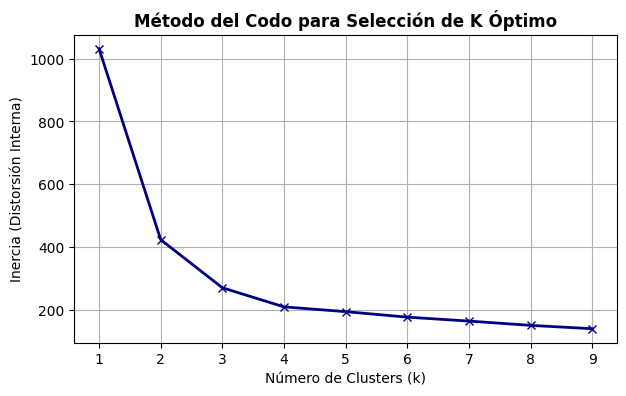

In [13]:
# =========================================================================
# PASO 3 - BLOQUE 4: Método del Codo para Selección de K Óptimo
# =========================================================================

inercias = []
K_rango = range(1, 10)

# Evaluamos la distorsión matemática desde 1 hasta 9 clusters
for k in K_rango:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

# Graficamos el método del codo para justificar visualmente nuestra elección
plt.figure(figsize=(7, 4))
plt.plot(K_rango, inercias, 'bx-', color='navy', linewidth=2)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (Distorsión Interna)')
plt.title('Método del Codo para Selección de K Óptimo', fontsize=12, fontweight='bold')
plt.grid(True)
plt.show()

In [14]:
# =========================================================================
# PASO 3 - BLOQUE 5: Aplicación de K-Means y Perfilamiento Estadístico
# =========================================================================

# Definimos K=3 basándonos en el quiebre óptimo de la gráfica del codo
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Aplicamos el algoritmo y agregamos la columna 'Cluster' de forma limpia al dataset original
df_cluster['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Imprimimos el promedio de cada variable por cada grupo encontrado
print("--- PERFIL ESTADÍSTICO DE LOS GRUPOS (PROMEDIOS DE CENTROIDES) ---")
print(df_cluster.groupby('Cluster')[columnas_clustering].mean().round(2))

--- PERFIL ESTADÍSTICO DE LOS GRUPOS (PROMEDIOS DE CENTROIDES) ---
         ingresos  frecuencia_uso  gasto_promedio  satisfaccion
Cluster                                                        
0         1740.70            9.09          158.03          8.80
1         1142.59            6.56           86.14          8.06
2          793.82            3.32           48.58          5.38


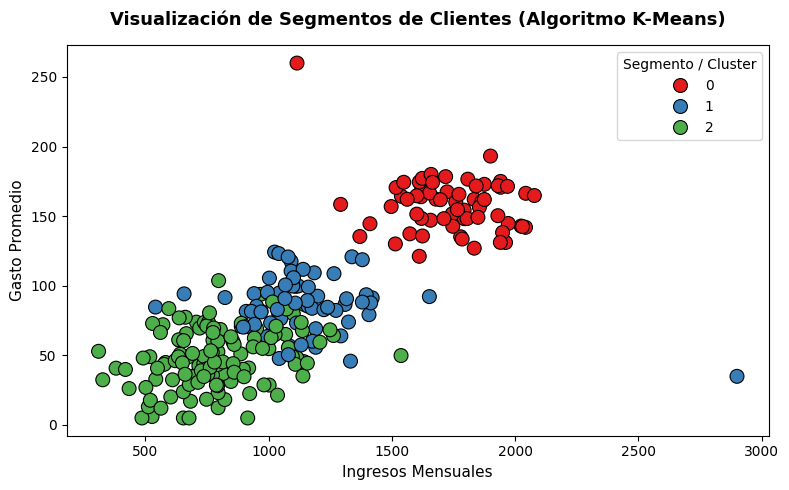

In [15]:
# =========================================================================
# PASO 3 - BLOQUE 6: Visualización Gráfica de los Segmentos Encontrados
# =========================================================================

# Graficamos la segmentación cruzando Ingresos vs Gasto Promedio [cite: 3]
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_cluster,
    x='ingresos',
    y='gasto_promedio',
    hue='Cluster',
    palette='Set1',
    s=100,
    edgecolor='black'
)

# Formato estético y títulos claros
plt.title('Visualización de Segmentos de Clientes (Algoritmo K-Means)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Ingresos Mensuales', fontsize=11)
plt.ylabel('Gasto Promedio', fontsize=11)
plt.legend(title='Segmento / Cluster')
plt.tight_layout()
plt.show()